<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science/blob/main/EDA1_Assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries


- **Pandas / NumPy** for data handling
- **Matplotlib / Seaborn** for visualization




In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

# Change this path if your CSV is stored somewhere else
DATA_PATH = "Cardiotocographic.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (2126, 14)


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,73.0000,0.5000,43.0000,2.4000,64.0000,0.9999,2.0000
1,132.0000,0.0064,0.0000,0.0064,0.0032,0.0000,0.0000,17.0000,2.1000,0.0000,10.4000,130.0000,0.0000,1.0000
2,133.0000,0.0033,0.0000,0.0083,0.0033,0.0000,0.0000,16.0000,2.1000,0.0000,13.4000,130.0000,0.0000,1.0000
3,134.0000,0.0026,0.0000,0.0077,0.0026,0.0000,0.0000,16.0000,2.4000,0.0000,23.0000,117.0000,1.0000,1.0000
4,131.9482,0.0065,0.0000,0.0081,0.0000,0.0000,0.0000,16.0000,2.4000,0.0000,19.9000,117.0000,1.0000,1.0000


## 2. Understand the Dataset

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

### Variable overview
 LB, AC, FM, UC, DL, DS, DP, ASTV, MSTV, ALTV, MLTV, Width, Tendency and NSP. The assignment gives tentative interpretations for the first 11 variables; those interpretations should be treated cautiously because the source itself uses words such as “likely”, “could”, and “may”.

## 3. Data Cleaning and Preparation



In [ ]:
# Missing values
missing_table = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)

display(missing_table)

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Data types
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

,Missing Count,Missing %
LB,21,0.9900
DS,21,0.9900
MLTV,21,0.9900
Width,21,0.9900
Tendency,21,0.9900
DP,21,0.9900
NSP,21,0.9900
AC,20,0.9400
FM,0,0.0000
UC,0,0.0000


Duplicate rows: 2

Data types:


,dtype
LB,float64
AC,float64
FM,float64
UC,float64
DL,float64
DS,float64
DP,float64
ASTV,float64
MSTV,float64
ALTV,float64


In [ ]:

numeric_check = {}

for col in df.columns:
    converted = pd.to_numeric(df[col], errors="coerce")
    numeric_check[col] = {
        "Original dtype": str(df[col].dtype),
        "Values becoming NaN after numeric conversion": int(converted.isna().sum() - df[col].isna().sum())
    }

display(pd.DataFrame(numeric_check).T)

,Original dtype,Values becoming NaN after numeric conversion
LB,float64,0
AC,float64,0
FM,float64,0
UC,float64,0
DL,float64,0
DS,float64,0
DP,float64,0
ASTV,float64,0
MSTV,float64,0
ALTV,float64,0


### Missing-value treatment


In [ ]:
# Work on a copy
clean_df = df.copy()

# Predictor columns
feature_cols = [c for c in clean_df.columns if c != "NSP"]

# Median-impute predictor columns
for col in feature_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Keep target-missing rows out of target-based analysis
eda_df = clean_df.dropna(subset=["NSP"]).copy()

print("Original shape:", df.shape)
print("After predictor imputation:", clean_df.shape)
print("Rows available for target analysis:", eda_df.shape)

print("\nRemaining missing values:")
display(clean_df.isna().sum().to_frame("missing"))

Original shape: (2126, 14)
After predictor imputation: (2126, 14)
Rows available for target analysis: (2105, 14)

Remaining missing values:


,missing
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


### Check `NSP` consistency

 `NSP` is stored as a floating-point column and most values are exactly 1, 2, or 3, but there are also values very close to those integers and a few unusual values. This suggests that the target column contains numerical perturbations/inconsistencies.

For EDA, we preserve the original `NSP` and create a separate `NSP_Class` by rounding to the nearest integer and retaining only classes 1–3. This is a **data-cleaning inference from the observed values**, not a clinical interpretation.

In [ ]:
# Create a cleaned categorical target for EDA
eda_df["NSP_Class"] = eda_df["NSP"].round()

# Values outside 1–3 are treated as invalid for class-based plots
valid_mask = eda_df["NSP_Class"].isin([1, 2, 3])
invalid_nsp = (~valid_mask).sum()

print("Invalid/unexpected NSP observations excluded from class-based analysis:", invalid_nsp)

class_df = eda_df.loc[valid_mask].copy()
class_df["NSP_Class"] = class_df["NSP_Class"].astype(int)

print("\nCleaned NSP class distribution:")
display(class_df["NSP_Class"].value_counts().sort_index().to_frame("Count"))

print("\nClass percentages:")
display((class_df["NSP_Class"].value_counts(normalize=True).sort_index() * 100).round(2).to_frame("Percentage"))

Invalid/unexpected NSP observations excluded from class-based analysis: 10

Cleaned NSP class distribution:


,Count
NSP_Class,
1,1630
2,293
3,172



Class percentages:


,Percentage
NSP_Class,
1,77.8000
2,13.9900
3,8.2100


## 4. Outlier Detection

detect and treat outliers if necessary. Here we use the IQR rule to **flag** potential outliers. We do not automatically delete them because an extreme observation can be a meaningful part of a real dataset.

In [ ]:
# IQR-based outlier summary
outlier_rows = []

for col in feature_cols:
    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((clean_df[col] < lower) | (clean_df[col] > upper)).sum()

    outlier_rows.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": int(count),
        "Outlier %": round(count / len(clean_df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("Outlier Count", ascending=False)
display(outlier_summary)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
2,FM,0.0000,0.0026,0.0026,-0.0038,0.0064,347,16.3200
9,ALTV,0.0000,11.0000,11.0000,-16.5000,27.5000,318,14.9600
6,DP,0.0000,0.0000,0.0000,0.0000,0.0000,284,13.3600
4,DL,0.0000,0.0033,0.0033,-0.0049,0.0082,125,5.8800
5,DS,0.0000,0.0000,0.0000,0.0000,0.0000,120,5.6400
10,MLTV,4.6000,10.8000,6.2000,-4.7000,20.1000,81,3.8100
8,MSTV,0.7000,1.7000,1.0000,-0.8000,3.2000,80,3.7600
1,AC,0.0000,0.0056,0.0056,-0.0084,0.0140,43,2.0200
3,UC,0.0019,0.0065,0.0047,-0.0052,0.0136,13,0.6100
0,LB,126.0000,140.0000,14.0000,105.0000,161.0000,10,0.4700


## 5. Statistical Summary

mean, median, standard deviation and interquartile range for each variable.

In [ ]:
numeric_cols = clean_df.select_dtypes(include=np.number).columns

summary = pd.DataFrame({
    "Mean": clean_df[numeric_cols].mean(),
    "Median": clean_df[numeric_cols].median(),
    "Std Dev": clean_df[numeric_cols].std(),
    "Q1": clean_df[numeric_cols].quantile(0.25),
    "Q3": clean_df[numeric_cols].quantile(0.75),
})

summary["IQR"] = summary["Q3"] - summary["Q1"]
summary["Min"] = clean_df[numeric_cols].min()
summary["Max"] = clean_df[numeric_cols].max()

display(summary.round(4))

,Mean,Median,Std Dev,Q1,Q3,IQR,Min,Max
LB,133.3402,133.0000,11.2144,126.0000,140.0000,14.0000,51.8425,214.0000
AC,0.0032,0.0016,0.0044,0.0000,0.0056,0.0056,-0.0193,0.0386
FM,0.0099,0.0000,0.0675,0.0000,0.0026,0.0026,-0.4806,0.9613
UC,0.0044,0.0045,0.0033,0.0019,0.0065,0.0047,-0.0149,0.0300
DL,0.0019,0.0000,0.0033,0.0000,0.0033,0.0033,-0.0154,0.0308
DS,0.0000,0.0000,0.0001,0.0000,0.0000,0.0000,-0.0014,0.0027
DP,0.0002,0.0000,0.0008,0.0000,0.0000,0.0000,-0.0053,0.0107
ASTV,46.9960,49.0000,18.8140,32.0000,61.0000,29.0000,-63.0000,162.0000
MSTV,1.3644,1.2000,1.1736,0.7000,1.7000,1.0000,-6.6000,13.8000
ALTV,10.2860,0.0000,21.2050,0.0000,11.0000,11.0000,-91.0000,182.0000


### 5.1 Skewness

In [ ]:
skewness = clean_df[numeric_cols].skew().sort_values(ascending=False)
display(skewness.to_frame("Skewness").round(4))

,Skewness
DS,8.4613
FM,6.7531
DP,6.4563
MSTV,4.1425
MLTV,3.5617
ALTV,2.9812
AC,2.0324
DL,2.0104
NSP,1.8109
UC,0.9742


"## 6. Univariate Visualizations

Histograms and boxplots are used to understand distributions and identify possible extreme values, as requested by the assignment.

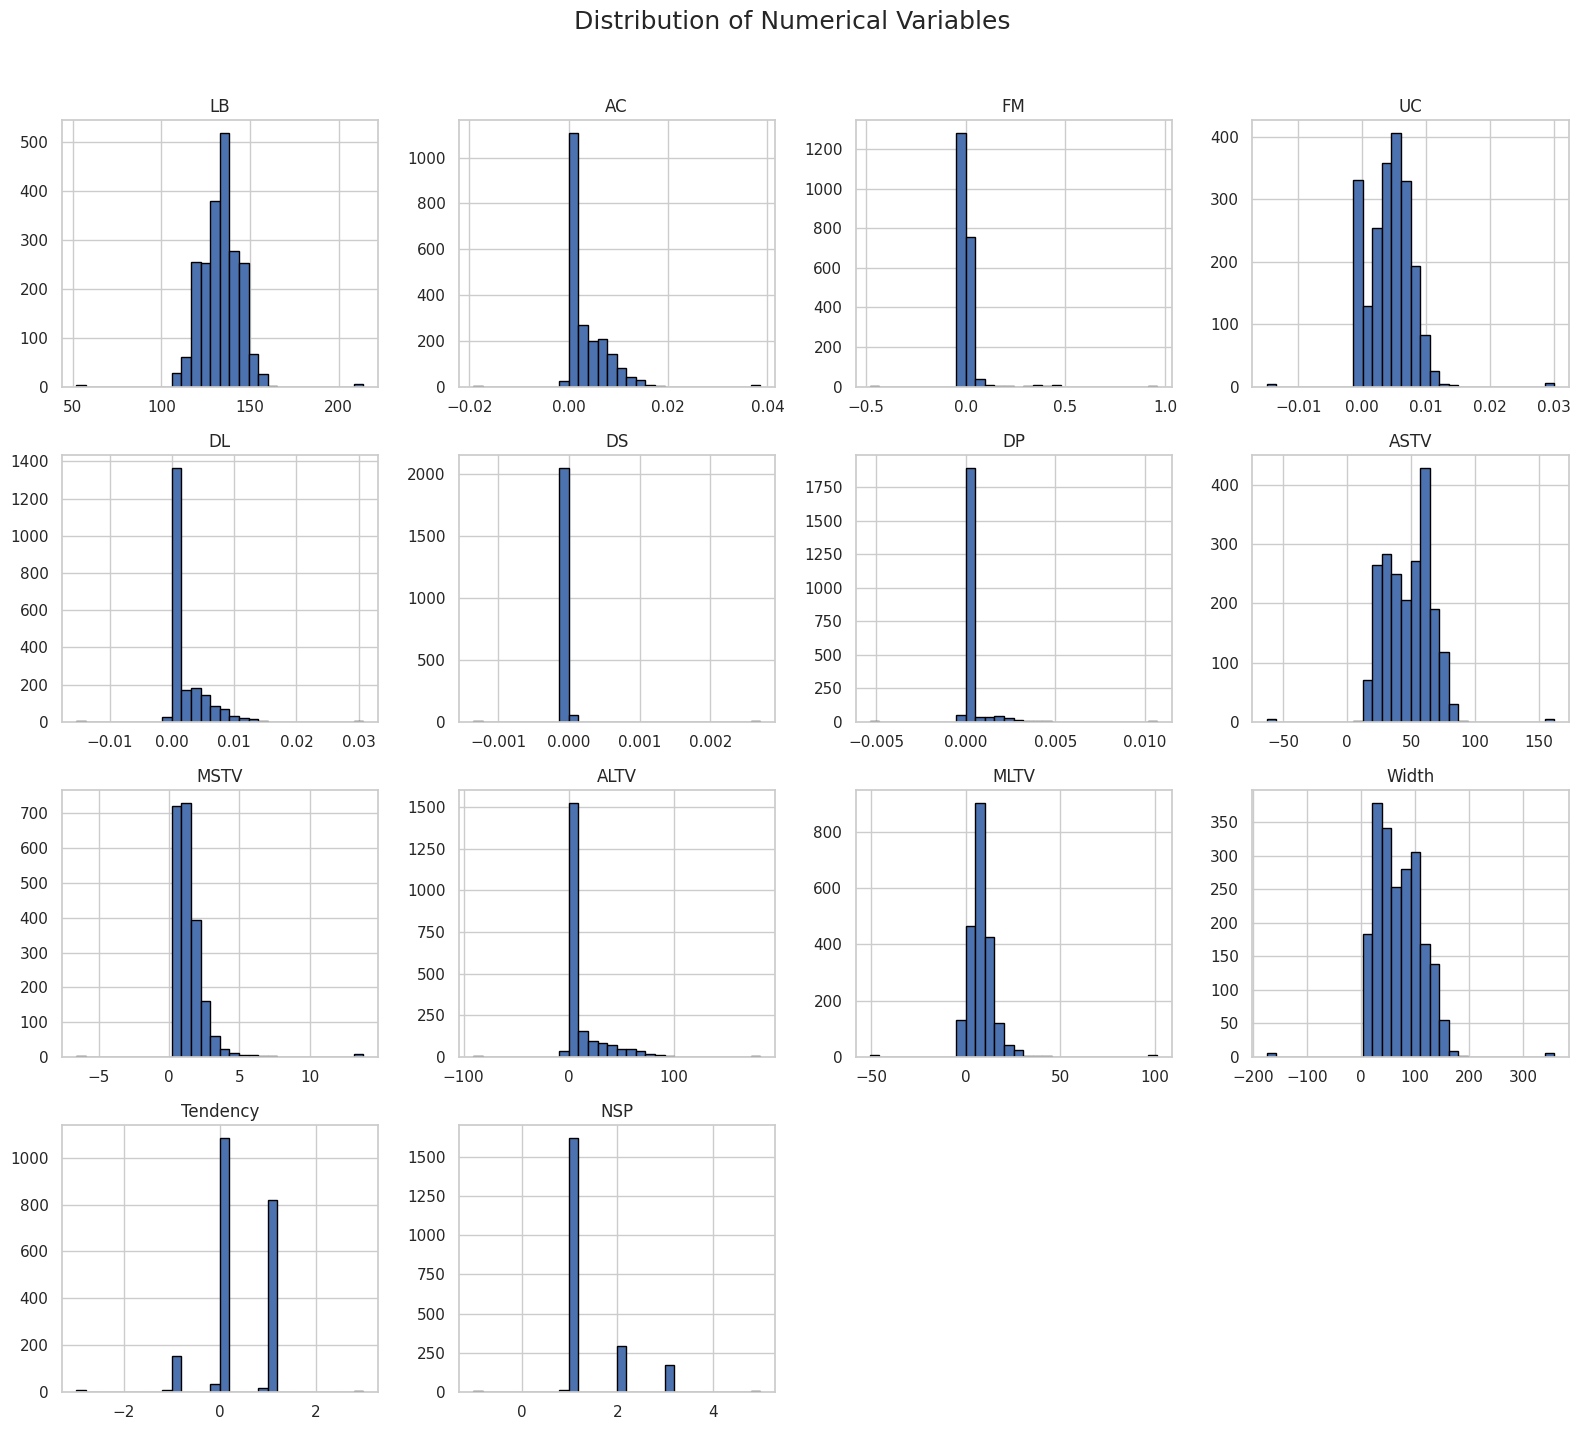

In [ ]:
# Histograms
clean_df[numeric_cols].hist(figsize=(16, 14), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numerical Variables", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

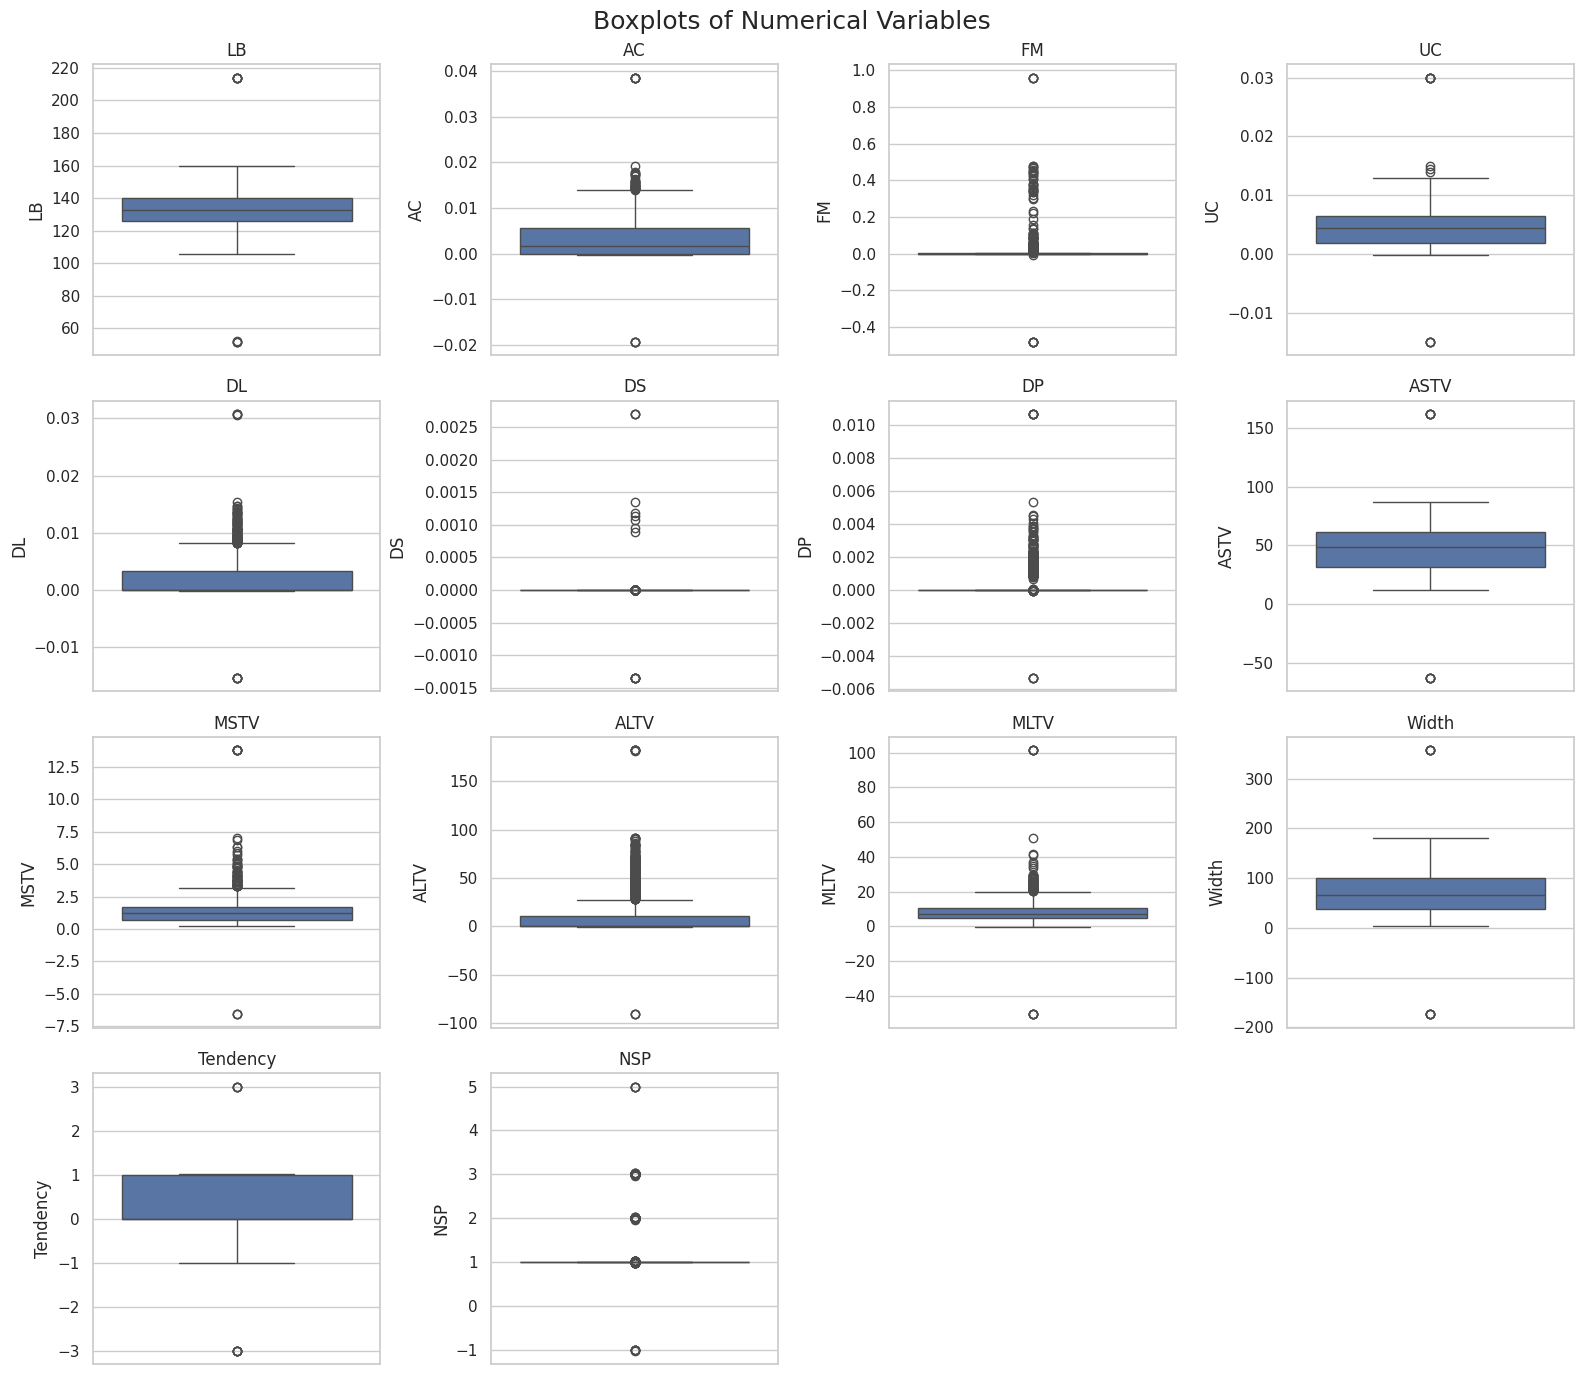

In [ ]:
# Boxplots
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=clean_df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Boxplots of Numerical Variables", fontsize=18)
plt.tight_layout()
plt.show()

## 7. Target/Class Distribution

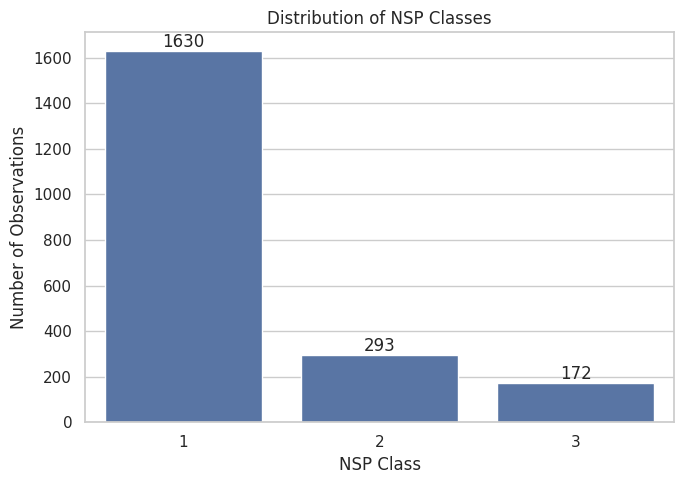

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=class_df, x="NSP_Class")
plt.title("Distribution of NSP Classes")
plt.xlabel("NSP Class")
plt.ylabel("Number of Observations")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## 8. Relationship Between Variables

Scatter plots are used for selected pairs, while a correlation heatmap provides an overall view of linear relationships. The assignment explicitly requests scatter plots or correlation heatmaps.

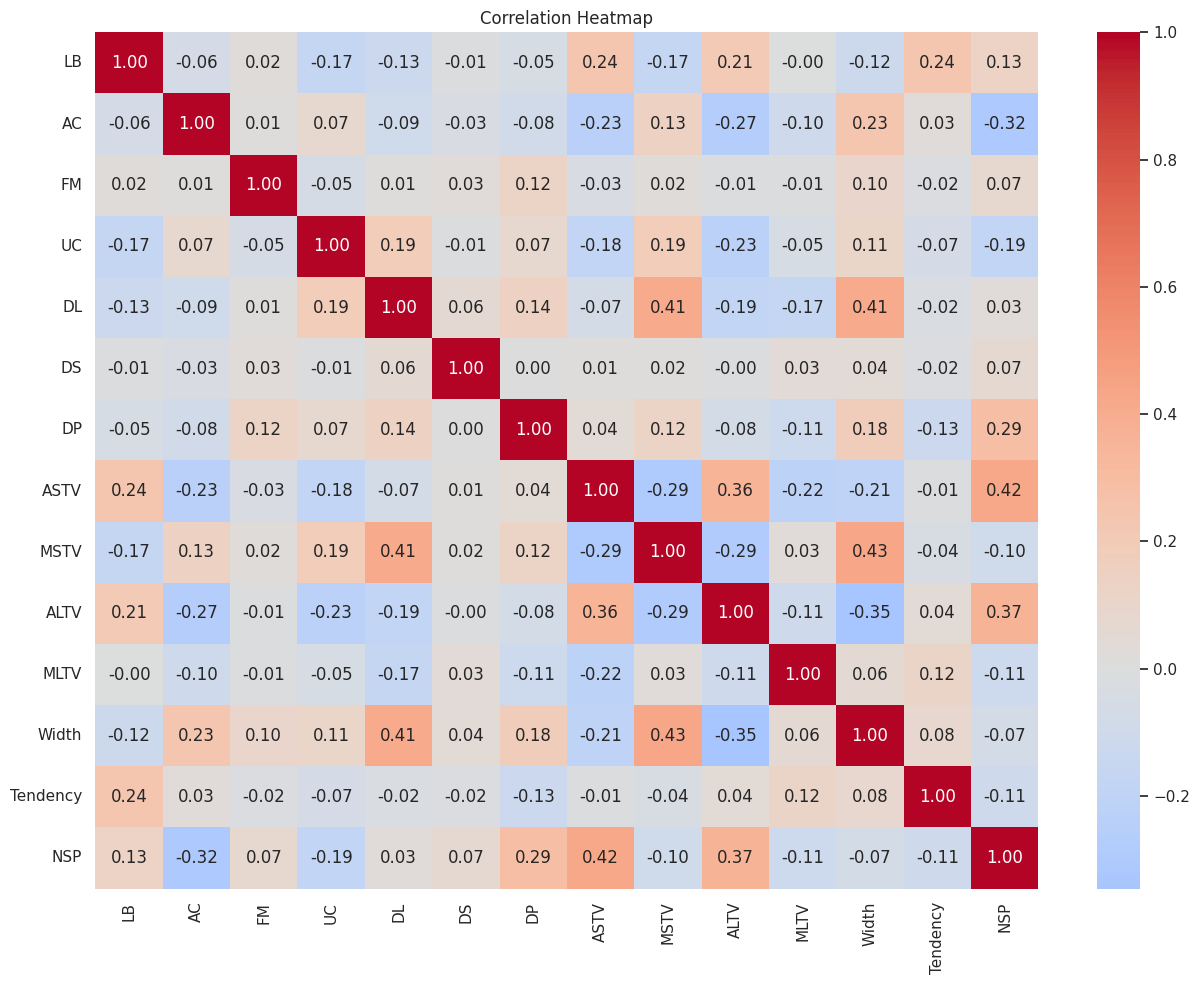

In [ ]:
# Correlation matrix
corr_matrix = clean_df[numeric_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

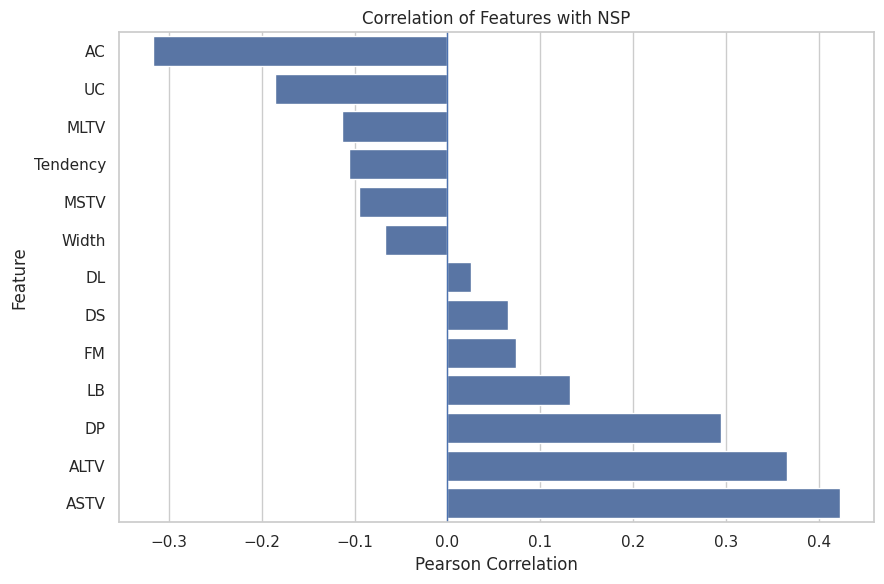

,Correlation with NSP
AC,-0.3169
UC,-0.1854
MLTV,-0.1137
Tendency,-0.1062
MSTV,-0.0951
Width,-0.0674
DL,0.0254
DS,0.0654
FM,0.0741
LB,0.1318


In [ ]:
# Correlation with NSP
nsp_corr = corr_matrix["NSP"].drop("NSP").sort_values()

plt.figure(figsize=(9, 6))
sns.barplot(x=nsp_corr.values, y=nsp_corr.index)
plt.title("Correlation of Features with NSP")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

display(nsp_corr.to_frame("Correlation with NSP").round(4))

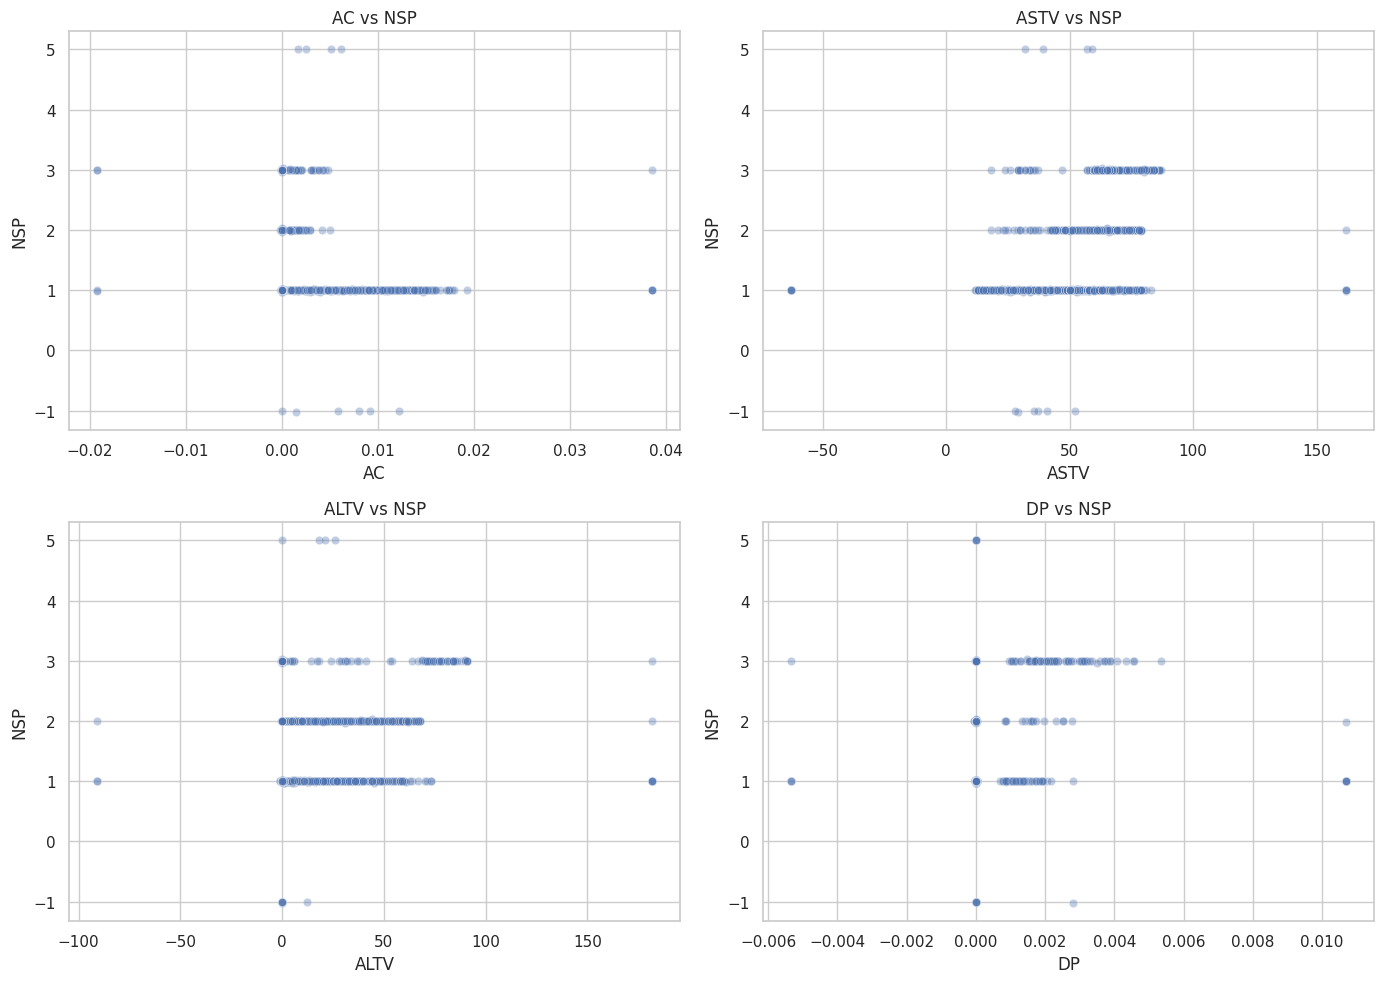

In [ ]:
# Selected scatter plots against NSP
selected_features = ["AC", "ASTV", "ALTV", "DP"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), selected_features):
    sns.scatterplot(data=eda_df, x=col, y="NSP", alpha=0.35, ax=ax)
    ax.set_title(f"{col} vs NSP")

plt.tight_layout()
plt.show()

## 9. Group Comparison by NSP Class

In [ ]:
# Compare feature means across cleaned NSP classes
group_means = class_df.groupby("NSP_Class")[feature_cols].mean().T
display(group_means.round(4))

NSP_Class,1,2,3
LB,131.9862,141.8502,131.8062
AC,0.0040,0.0003,0.0004
FM,0.0071,0.0182,0.0234
UC,0.0048,0.0023,0.0037
DL,0.0019,0.0007,0.0035
DS,-0.0000,0.0000,0.0000
DP,0.0001,0.0001,0.0012
ASTV,42.3923,62.1582,65.1573
MSTV,1.4589,0.7090,1.5265
ALTV,5.4976,29.1941,24.4325


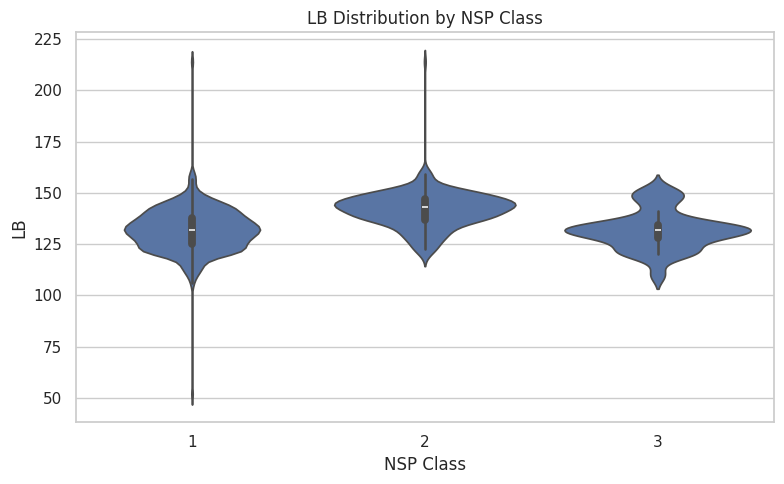

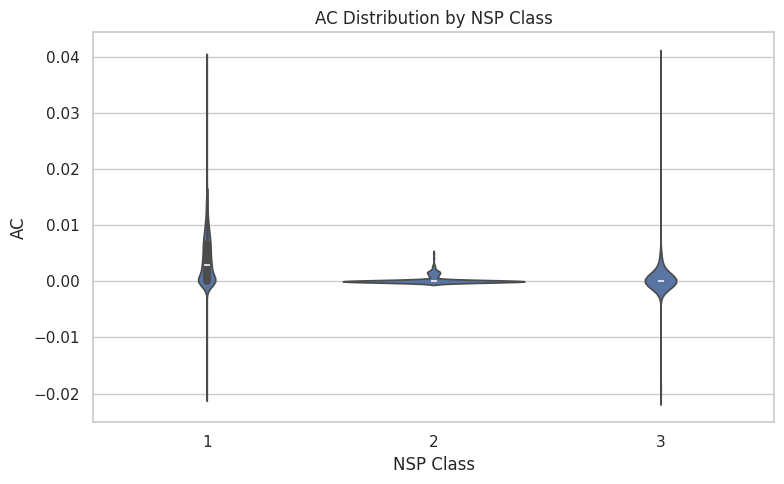

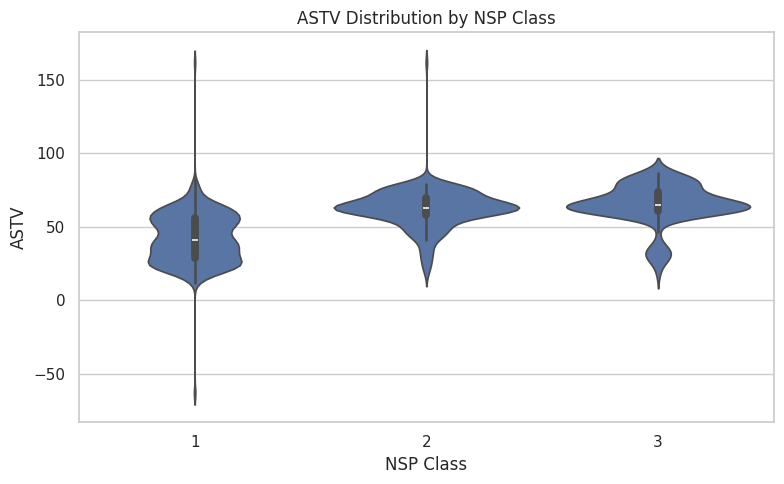

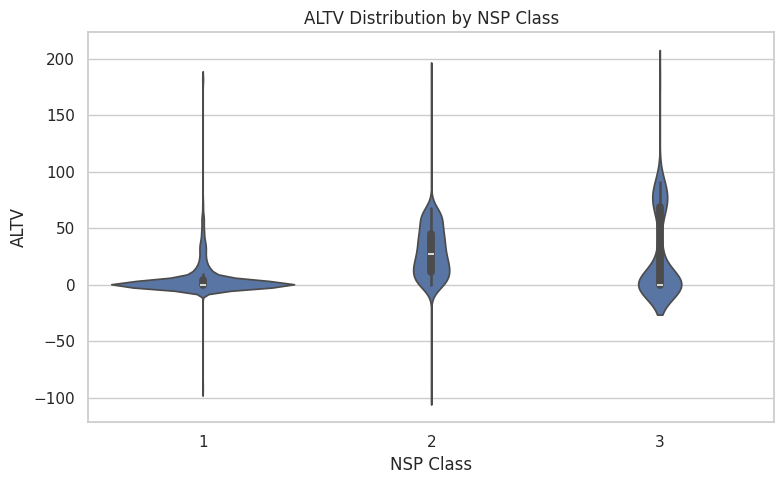

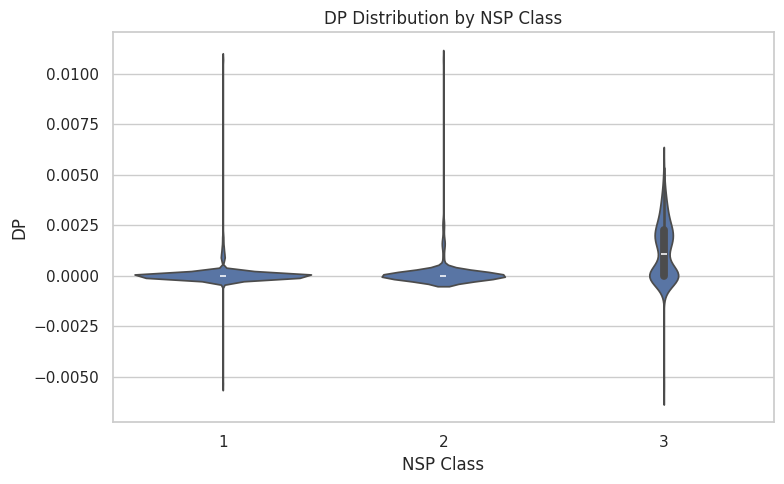

In [ ]:
# Violin plots for selected features by NSP class
selected_features = ["LB", "AC", "ASTV", "ALTV", "DP"]

for col in selected_features:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=class_df, x="NSP_Class", y=col, inner="box")
    plt.title(f"{col} Distribution by NSP Class")
    plt.xlabel("NSP Class")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 10. Pair Plot

A pair plot is an advanced visualization requested as an optional deeper-analysis technique in the assignment. Because plotting every feature can become difficult to read, we use a selected subset of variables.

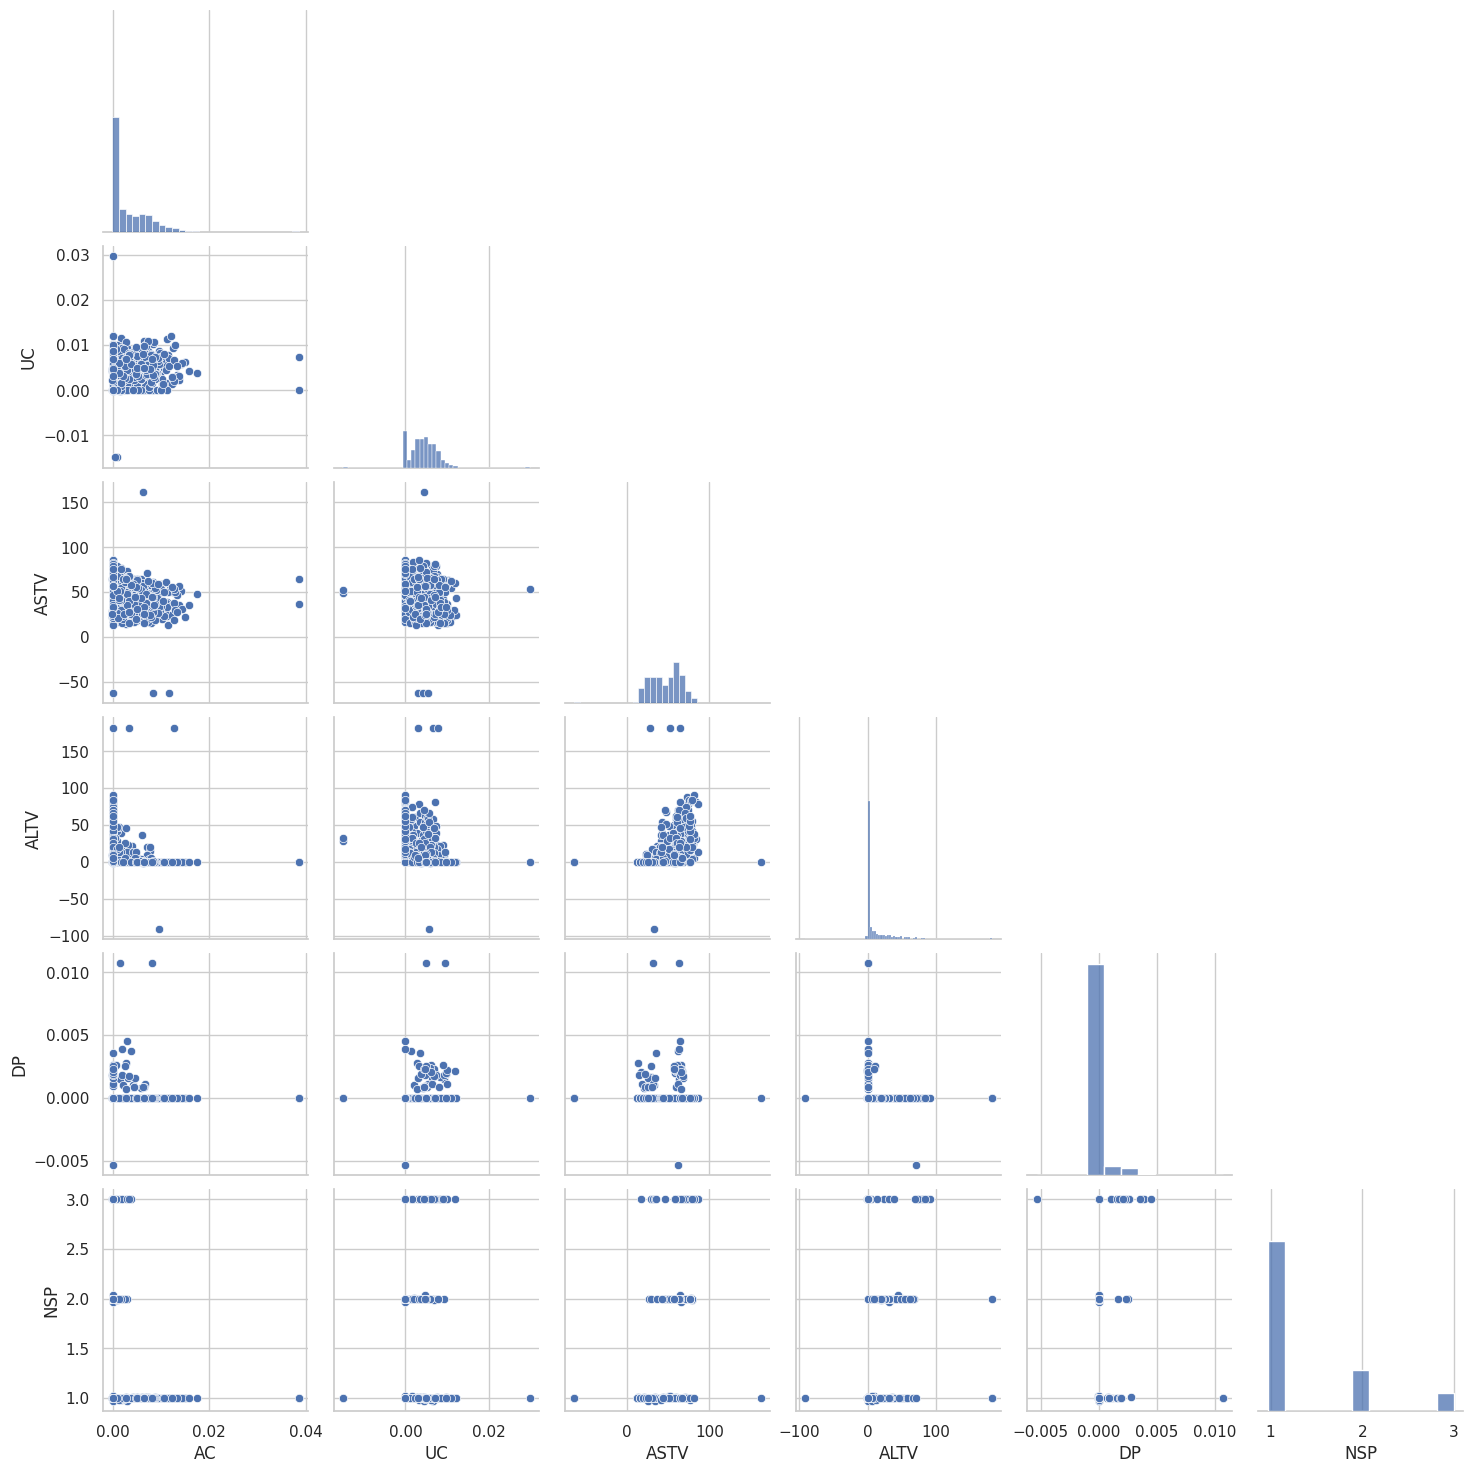

In [ ]:
pair_cols = ["AC", "UC", "ASTV", "ALTV", "DP", "NSP"]

sns.pairplot(
    class_df[pair_cols].sample(min(600, len(class_df)), random_state=42),
    corner=True,
    diag_kind="hist"
)
plt.show()

## 11. Automatic Insight Extraction

In [ ]:
# Generate a concise set of numerical findings
top_positive = nsp_corr.sort_values(ascending=False).head(3)
top_negative = nsp_corr.sort_values().head(3)

print("Dataset size:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values before cleaning:")
display(missing_table)

print("\nStrongest positive correlations with NSP:")
display(top_positive.to_frame("Correlation"))

print("\nStrongest negative correlations with NSP:")
display(top_negative.to_frame("Correlation"))

print("\nCleaned NSP class distribution:")
display(class_df["NSP_Class"].value_counts().sort_index().to_frame("Count"))

Dataset size: (2126, 14)
Duplicate rows: 2

Missing values before cleaning:


,Missing Count,Missing %
LB,21,0.9900
DS,21,0.9900
MLTV,21,0.9900
Width,21,0.9900
Tendency,21,0.9900
DP,21,0.9900
NSP,21,0.9900
AC,20,0.9400
FM,0,0.0000
UC,0,0.0000



Strongest positive correlations with NSP:


,Correlation
ASTV,0.4227
ALTV,0.3658
DP,0.2945



Strongest negative correlations with NSP:


,Correlation
AC,-0.3169
UC,-0.1854
MLTV,-0.1137



Cleaned NSP class distribution:


,Count
NSP_Class,
1,1630
2,293
3,172


## 12. Key Findings

1. The dataset contains **2,126 rows and 14 columns**.
2. Several columns contain missing values. The missing observations are handled using median imputation for predictors, while missing NSP` values are excluded from target-based analysis.
3. The columns are numeric in the supplied CSV, so no major string-to-numeric conversion is required.
4. Potential outliers exist in multiple variables according to the IQR rule. They are flagged rather than automatically deleted.
5. The raw NSP column contains mostly values corresponding to 1, 2 and 3, but also contains small numerical deviations and a few unexpected values. A separate cleaned class variable is therefore created for categorical EDA.
6. The correlation analysis should be interpreted as **association, not causation**.
7. The strongest correlations with the raw NSP observed in this dataset are expected to be visible in the generated correlation table/bar chart. The exact values are calculated directly from the CSV when the notebook runs.
8. The class distribution is imbalanced, with class 1 substantially more frequent than classes 2 and 3. This matters if the dataset is later used for predictive modeling.

These findings satisfy the assignment's requirement to identify patterns and discuss their possible implications.

## 13. Conclusion

The exploratory analysis provides a structured understanding of the Cardiotocographic dataset. The data was inspected for dimensions, types, missing values, duplicates and potential outliers. Statistical measures such as mean, median, standard deviation and IQR were calculated. Histograms and boxplots were used to study distributions, while class plots, scatter plots, violin plots, pair plots and a correlation heatmap were used to investigate relationships and patterns.

The cleaning process intentionally keeps the original data available and applies conservative transformations. In particular, the raw NSP values are preserved and a separate class variable is created for EDA because the supplied CSV contains small deviations from integer class values.

For future work, the cleaned data could be used for feature selection and predictive modeling. Before doing so, class imbalance, outliers, feature scaling, and the meaning of the target variable should be investigated carefully.

The assignment specifically requests a notebook containing code, visualizations and explanations plus a brief findings report.